In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = yf.download('^GSPC', start='2015-01-01', end='2026-01-01')
data.columns = data.columns.get_level_values(0)
display(data.head())
data.info()
data.shape

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2766 non-null   float64
 1   High    2766 non-null   float64
 2   Low     2766 non-null   float64
 3   Open    2766 non-null   float64
 4   Volume  2766 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.7 KB


(2766, 5)

In [2]:
data.to_csv('../data/sp500_raw.csv')

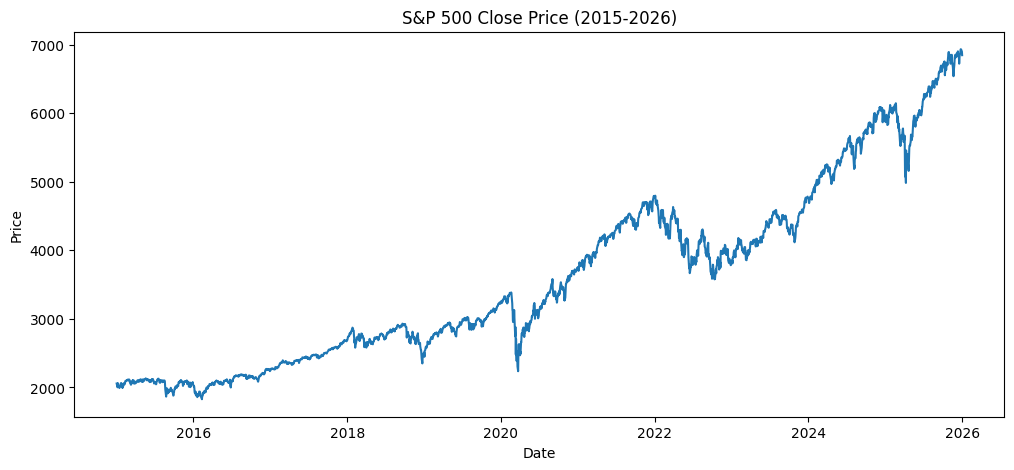

In [3]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data['Close'])
plt.title('S&P 500 Close Price (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

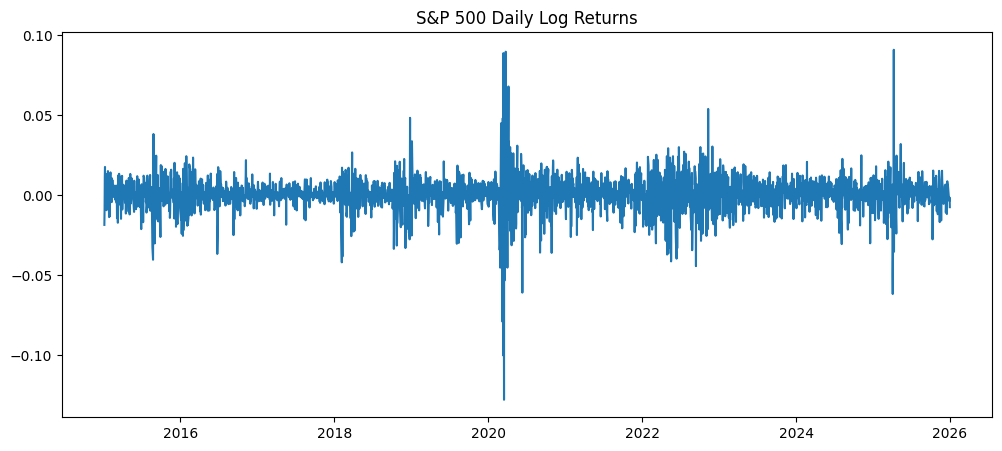

In [4]:
data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()
plt.figure(figsize=(12, 5))
plt.plot(data.index, data['log_return'])
plt.title('S&P 500 Daily Log Returns')
plt.show()

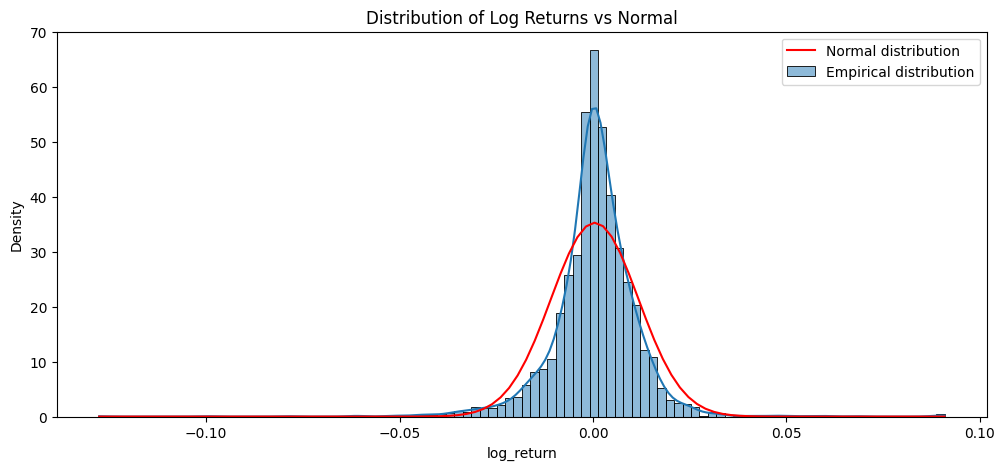

In [5]:
from scipy import stats

# Plot 1 - linear scale
plt.figure(figsize=(12,5))
sns.histplot(data['log_return'], kde = True, stat='density', bins=100, label='Empirical distribution')

mu = data['log_return'].mean()
var  = data['log_return'].std()
x = np.linspace(data['log_return'].min(), data['log_return'].max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, var), 'r-', label='Normal distribution')
plt.legend()
plt.title('Distribution of Log Returns vs Normal')
plt.show()

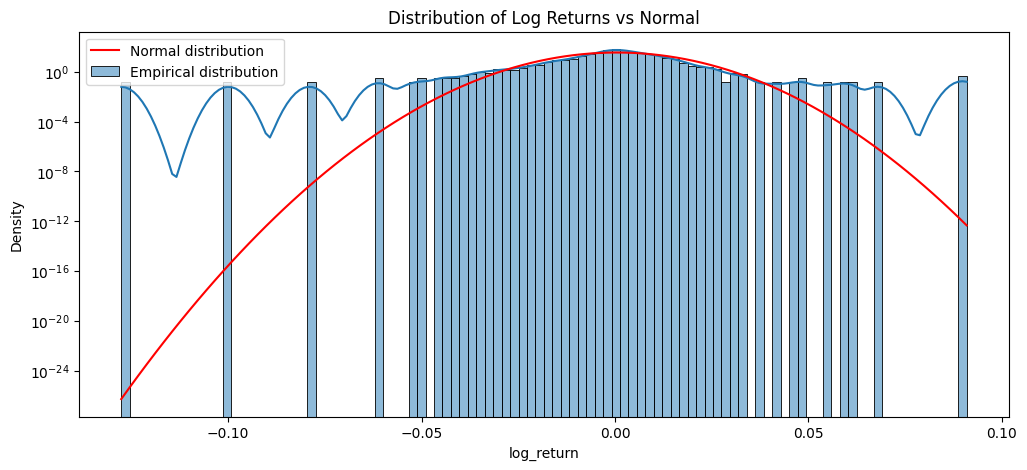

In [6]:
# Plot 2 - Logarithmic scale (shows fat tails: extreme returns occur far more often than a normal distribution would predict)
plt.figure(figsize=(12,5))
sns.histplot(data['log_return'], kde = True, stat='density', bins=100, label='Empirical distribution')

mu = data['log_return'].mean()
var  = data['log_return'].std()
x = np.linspace(data['log_return'].min(), data['log_return'].max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, var), 'r-', label='Normal distribution')
plt.yscale('log')
plt.legend()
plt.title('Distribution of Log Returns vs Normal')
plt.savefig('../docs/fat_tails.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
# Jarque-Bera test
jb_stat, jb_pvalue = stats.jarque_bera(data['log_return'])
print(f"Jarque-Bera statistic: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.10f}")

Jarque-Bera statistic: 29305.6421
p-value: 0.0000000000


In [8]:
# ADF test
from statsmodels.tsa.stattools import adfuller

adf_price = adfuller(data['Close'])
print(f"ADF statistic (price): {adf_price[0]:.4f}, p-value: {adf_price[1]:.10f}")

adf_returns = adfuller(data['log_return'])
print(f"ADF statistic (Logarithmic returns): {adf_returns[0]:.4f}, p-value: {adf_returns[1]:.10f}")

ADF statistic (price): 0.8246, p-value: 0.9920230453
ADF statistic (Logarithmic returns): -16.9823, p-value: 0.0000000000


In [9]:
# Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox

squared_returns = data['log_return']**2
lb_test = acorr_ljungbox(squared_returns, lags=[10], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
10  2983.103466        0.0


## Summary of Statistical Tests 

| Test | Statistic | p-value | Conclusion |
|---|---|---|---|
| Jarque-Bera (normality) | 29405.91 | < 0.001 | Reject H₀ — returns are not normally distributed |
| ADF (price) | 0.8266 | 0.992 | No reasons to reject H₀ — price series is non-stationary |
| ADF (log returns) | -16.9525 | < 0.001 | Reject H₀ — returns are stationary |
| Ljung-Box (squared returns, lag 10) | 2982.49 | < 0.001 | Reject H₀ — volatility clustering confirmed |